# **ImageProcessor & Metrics — interactive demo (users)**

## Libraries

In [1]:
import numpy as np, matplotlib.pyplot as plt, warnings, random
from pathlib import Path
warnings.filterwarnings('ignore')

from core.config import LayoutConfig, GlobalConfig, ImageProcessorConfig
from operators.image_processor import ImageProcessor
from operators.image_operator import Operator
from operators.image_io import ImageIO
from operators.metrics import MetricEvaluator, SSIM
from utils.nd_tools import show_plane  # helper for plane visualization
from utils.decorators import timer # helper for benchmarking

## Configurations

In [2]:
# ImageIO configuration: NumPy input/output, HWC layout
layout_cfg = LayoutConfig(layout_name="HWC", layout_framework="numpy", layout_ensured_name="HWC")
global_cfg  = GlobalConfig(framework="numpy", output_format="numpy")
io = ImageIO(layout_cfg=layout_cfg, global_cfg=global_cfg)

print("Initialized ImageIO — framework:", global_cfg.framework, "| output:", global_cfg.output_format)

Initialized ImageIO — framework: numpy | output: numpy


## Image Directory

In [3]:
root = Path.cwd().parent.parent.parent / "03_EXAMPLES_DATA" / "Images"
images_path = sorted([str(p) for p in root.rglob("*.png")])
rand = random.randint(0, len(images_path) - 2)
print("Found images:", len(images_path))

Found images: 672


## Load random image and build runners

In [4]:
image = io.read_image(images_path[rand], framework="numpy")

def _noising(img, sigma=0.1, framework="numpy", output_format="numpy", processor_strategy="vectorized"):

    func = lambda x: Operator(
        x,
        clip=True,
        layout_cfg=LayoutConfig(layout_name="HWC", layout_framework="numpy"),
        global_cfg=GlobalConfig(framework=framework, output_format=output_format),
    ).noise(sigma=sigma)

    proc = ImageProcessor(
        img_process_cfg=ImageProcessorConfig(function=func, processor_strategy=processor_strategy),
        layout_cfg=LayoutConfig(layout_name="HWC", layout_framework="numpy"),
        global_cfg=GlobalConfig(framework=framework, output_format=output_format),
    )
    return proc(img)

image_noised = _noising(image, sigma=0.1)

print("Computed noised (numpy strategy). Shape:", image_noised.shape)

Computed noised (numpy strategy). Shape: (1356, 2040, 3)


## Visualisation

In [5]:
evaluator = MetricEvaluator(metrics=["mse","mae","rmse","nrmse","psnr","ssim","ms-ssim","lpips"], return_dict=True)
evaluator.available_metrics["ssim"] = (SSIM, {"return_map": False})

results = evaluator(image, image_noised)

print("\n=== Metric Evaluation Results ===")
for k, v in results.items():
    print(f"{k.upper():8s} : {v}")


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: c:\Users\ainau\AppData\Local\Programs\Python\Python313\Lib\site-packages\lpips\weights\v0.1\vgg.pth

=== Metric Evaluation Results ===
MSE      : 0.00883642490953207
MAE      : 0.07468704879283905
RMSE     : 0.09398069232702255
NRMSE    : 0.09434404969215393
PSNR     : 20.537234087548573
SSIM     : 0.1900544911623001
MS-SSIM  : 0.6729000806808472
LPIPS    : 0.5234230756759644


## Visualisation

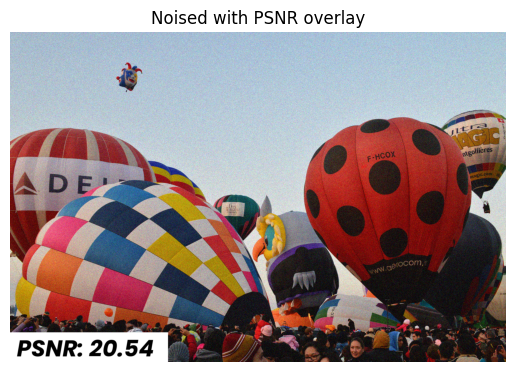

In [6]:
wrapped = io.treat_image_and_add_metric(
    image_noised,
    image,
    metric="psnr",
    subfolder="fonts",
    fname="Poppins-BoldItalic.ttf",
)
plt.imshow(wrapped); plt.axis("off"); plt.title("Noised with PSNR overlay")
plt.show()